# Check data for the spatial transcriptome dataset

Data source: https://www.10xgenomics.com/cn/datasets/human-prostate-cancer-adenocarcinoma-with-invasive-carcinoma-ffpe-1-standard-1-3-0

# 1) Check image and count data

In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import re
import skimage
import skimage.io
import skimage.transform
import tifffile
import scipy
import scanpy as sc

(25219, 27482, 3)


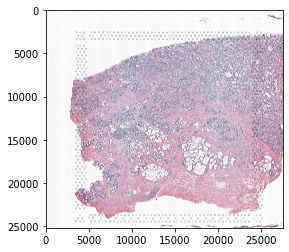

In [26]:
image_file = "./Sample_data/Dataset_HPC/Visium_FFPE_Human_Prostate_Cancer_image.tif"
image = skimage.io.imread(os.path.join(image_file))
print(image.shape)
plt.imshow(image)
plt.show()

In [97]:
### Read the counts
test = sc.read_mtx("./Sample_data/Dataset_HPC/filtered_feature_bc_matrix/matrix.mtx")
count = scipy.sparse.csr_matrix.toarray(test.X)

In [98]:
barcodes = pd.read_csv('./Sample_data/Dataset_HPC/filtered_feature_bc_matrix/barcodes.tsv', 
                       header=None)
barcodes

,0
0,AAACAAGTATCTCCCA-1
1,AAACACCAATAACTGC-1
2,AAACAGAGCGACTCCT-1
3,AAACAGCTTTCAGAAG-1
4,AAACAGGGTCTATATT-1
...,...
4366,TTGTTGTGTGTCAAGA-1
4367,TTGTTTCACATCCAGG-1
4368,TTGTTTCATTAGTCTA-1
4369,TTGTTTCCATACAACT-1


In [99]:
genes = pd.read_csv('./Sample_data/Dataset_HPC/filtered_feature_bc_matrix/features.tsv', 
                       header=None, sep='\t')
genes

,0,1,2
0,ENSG00000187634,SAMD11,Gene Expression
1,ENSG00000188976,NOC2L,Gene Expression
2,ENSG00000187961,KLHL17,Gene Expression
3,ENSG00000187583,PLEKHN1,Gene Expression
4,ENSG00000187642,PERM1,Gene Expression
...,...,...,...
17938,ENSG00000258992,TSPY1,Gene Expression
17939,ENSG00000114374,USP9Y,Gene Expression
17940,ENSG00000067048,DDX3Y,Gene Expression
17941,ENSG00000154620,TMSB4Y,Gene Expression


In [100]:
count = count.T

In [101]:
pd_count = pd.DataFrame(count.astype(int), columns=genes.loc[:, 1].values, index=barcodes.loc[:, 0].values)

In [102]:
pd_count

,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,C1orf159,...,SRY,ZFY,PCDH11Y,AMELY,TBL1Y,TSPY1,USP9Y,DDX3Y,TMSB4Y,KDM5D
AAACAAGTATCTCCCA-1,0,1,0,0,0,1,0,0,0,1,...,0,1,0,0,0,0,0,1,0,0
AAACACCAATAACTGC-1,1,1,0,0,0,2,0,2,0,0,...,0,0,0,0,0,0,0,2,0,2
AAACAGAGCGACTCCT-1,0,7,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
AAACAGCTTTCAGAAG-1,0,3,0,1,0,2,1,2,0,0,...,0,0,0,0,1,0,0,1,0,4
AAACAGGGTCTATATT-1,0,1,0,0,0,2,2,2,0,0,...,0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTGTGTGTCAAGA-1,0,0,0,0,0,3,0,2,0,0,...,0,0,0,0,0,0,0,2,0,2
TTGTTTCACATCCAGG-1,0,3,0,0,0,2,2,1,0,0,...,0,1,0,0,0,0,1,0,1,0
TTGTTTCATTAGTCTA-1,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
TTGTTTCCATACAACT-1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [103]:
pd_count.to_csv('./output/Dataset_HPC//count_df.csv')

In [79]:
## Important
## Sum all isoforms
gene_names = list(set(pd_count.columns.values))
gene_names.sort()
print(len(gene_names))

gene_names_unique = []
gene_names_multiple = []
from tqdm import tqdm
for gene_name in tqdm(gene_names):
    if np.sum(pd_count.columns.values == gene_name) == 1:
        gene_names_unique.append(gene_name)
    else:
        gene_names_multiple.append(gene_name)
print(len(gene_names_unique))
print(len(gene_names_multiple), gene_names_multiple)

17941


100%|██████████| 17941/17941 [00:04<00:00, 3938.48it/s]

17939
2 ['HSPA14', 'TBCE']


In [80]:
column_ids = []
for gene_name in tqdm(gene_names):
    column_ids.append(np.argmax(pd_count.columns.values == gene_name))

100%|██████████| 17941/17941 [00:04<00:00, 4134.33it/s]


In [81]:
pd_count_temp = pd_count.iloc[:, column_ids]

In [82]:
for gene_name in gene_names_multiple:
    pd_count_temp.loc[:, gene_name] = np.sum(pd_count.loc[:, gene_name], axis=1)

/project/DPDS/Xiao_lab/shared/qin_zhou/environments/envs/MicNet/lib/python3.6/site-packages/pandas/core/indexing.py:1781: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[item_labels[indexer[info_axis]]] = value


In [83]:
pd_count = pd_count_temp

In [84]:
np.sum(pd_count, axis=0)

A1BG          75
A1CF           2
A2M        23129
A2ML1          2
A3GALT2        8
           ...  
ZXDC        3305
ZYG11A        65
ZYG11B      2161
ZYX         8997
ZZEF1       5521
Length: 17941, dtype: int64

In [85]:
print("Original count size: {}".format(np.shape(pd_count)))

# Remove all 0s genes
gene_sum = np.sum(pd_count, axis=0)
gene_names = gene_sum.index.values[gene_sum > 0]
pd_count_norm = pd_count.loc[:, gene_names]
_pd_count_norm = pd.DataFrame(columns=gene_names, index=pd_count_norm.index.values)

# CPM normalization
from tqdm import tqdm
for n_row in tqdm(range(len(pd_count_norm))):
    # I do not understand why this code does not work
    # pd_count_norm.iloc[n_row, :] = pd_count_norm.iloc[n_row, :] / np.sum(pd_count_norm.iloc[n_row, :]) * 1000000
    _pd_count_norm.iloc[n_row, :] = pd_count_norm.iloc[n_row, :] / np.sum(pd_count_norm.iloc[n_row, :]) * 1000000
pd_count_norm = _pd_count_norm

Original count size: (4371, 17941)


100%|██████████| 4371/4371 [00:15<00:00, 281.63it/s]


In [86]:
np.shape(pd_count_norm)

(4371, 16905)

In [87]:
pd_count_norm

,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AADAC,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1
AAACAAGTATCTCCCA-1,0,0,228.833,0,0,114.416,0,0,114.416,0,...,0,0,0,0,114.416,0,0,0,457.666,457.666
AAACACCAATAACTGC-1,0,0,358.963,0,0,143.585,0,0,0,0,...,0,0,0,0,0,71.7927,0,143.585,502.549,71.7927
AAACAGAGCGACTCCT-1,0,0,125.96,0,0,62.9802,0,62.9802,0,0,...,0,62.9802,0,0,188.941,0,0,62.9802,62.9802,314.901
AAACAGCTTTCAGAAG-1,0,0,855.714,0,0,65.8241,0,0,0,0,...,0,0,0,0,131.648,65.8241,65.8241,65.8241,197.472,131.648
AAACAGGGTCTATATT-1,0,0,1133.22,0,0,0,0,125.913,0,0,...,0,0,0,0,0,0,125.913,0,125.913,125.913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTGTGTGTCAAGA-1,0,0,472.925,0,0,0,0,0,0,0,...,0,78.8208,0,0,0,78.8208,0,78.8208,236.463,78.8208
TTGTTTCACATCCAGG-1,0,0,558.088,0,0,0,0,0,0,0,...,93.0146,93.0146,0,0,93.0146,93.0146,0,93.0146,186.029,93.0146
TTGTTTCATTAGTCTA-1,0,0,0,0,0,199.681,0,0,0,0,...,0,0,0,0,0,0,0,0,199.681,0
TTGTTTCCATACAACT-1,0,0,908.595,0,0,0,0,181.719,0,0,...,0,0,0,0,0,0,0,0,363.438,0


In [92]:
pd_count_norm

,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AADAC,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1
AAACAAGTATCTCCCA-1,0,0,228.833,0,0,114.416,0,0,114.416,0,...,0,0,0,0,114.416,0,0,0,457.666,457.666
AAACACCAATAACTGC-1,0,0,358.963,0,0,143.585,0,0,0,0,...,0,0,0,0,0,71.7927,0,143.585,502.549,71.7927
AAACAGAGCGACTCCT-1,0,0,125.96,0,0,62.9802,0,62.9802,0,0,...,0,62.9802,0,0,188.941,0,0,62.9802,62.9802,314.901
AAACAGCTTTCAGAAG-1,0,0,855.714,0,0,65.8241,0,0,0,0,...,0,0,0,0,131.648,65.8241,65.8241,65.8241,197.472,131.648
AAACAGGGTCTATATT-1,0,0,1133.22,0,0,0,0,125.913,0,0,...,0,0,0,0,0,0,125.913,0,125.913,125.913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTGTGTGTCAAGA-1,0,0,472.925,0,0,0,0,0,0,0,...,0,78.8208,0,0,0,78.8208,0,78.8208,236.463,78.8208
TTGTTTCACATCCAGG-1,0,0,558.088,0,0,0,0,0,0,0,...,93.0146,93.0146,0,0,93.0146,93.0146,0,93.0146,186.029,93.0146
TTGTTTCATTAGTCTA-1,0,0,0,0,0,199.681,0,0,0,0,...,0,0,0,0,0,0,0,0,199.681,0
TTGTTTCCATACAACT-1,0,0,908.595,0,0,0,0,181.719,0,0,...,0,0,0,0,0,0,0,0,363.438,0


In [93]:
pd_count_norm.to_csv("./output/Dataset_HPC/1_pd_count_norm_prostate.csv", index=True)

# calculate mean and variance

In [89]:
count_stat = pd.DataFrame(columns=pd_count_norm.columns.values, index=["mean", "std", "tile_95", "non_zero_p", "max"])
count_stat.loc['mean', :] = np.average(pd_count_norm, axis=0)
count_stat.loc['std', :] = np.std(pd_count_norm, axis=0)
count_stat.loc['tile_95', :] = np.quantile(pd_count_norm, 0.95, axis=0)
count_stat.loc['non_zero_p', :] = np.sum(np.array(pd_count_norm) > 0, axis=0)/pd_count_norm.shape[0]
count_stat.loc['max', :] = np.max(pd_count_norm, axis=0)

In [90]:
count_stat.to_csv("./output/Dataset_HPC/1_count_stat_prostate.csv")

In [66]:
## re-formating the location file
pd_meta = pd.read_csv(
     './run_data/human_prostate_cancer_ffpe.loc.csv',
    #header=None,   # file has no header row
    #names=["Row", "Col", "X", "Y"]  # manually assign column names
    sep=","
)
pd_meta.columns = ['X', 'Y']
pd_meta.index = pd_count.index
pd_meta

,X,Y
AAACAAGTATCTCCCA-1,16467,19883
AAACACCAATAACTGC-1,18720,7839
AAACAGAGCGACTCCT-1,7378,18737
AAACAGCTTTCAGAAG-1,14679,6394
AAACAGGGTCTATATT-1,15690,6973
...,...,...
TTGTTGTGTGTCAAGA-1,11665,16264
TTGTTTCACATCCAGG-1,18473,11176
TTGTTTCATTAGTCTA-1,18975,9434
TTGTTTCCATACAACT-1,15188,9005


In [75]:
pd_meta.to_csv('./output/Dataset_HPC/location_prostate_cancer.csv',index=True)


In [67]:
indexes = pd_meta.index.values

In [68]:
# Get image patch
def get_image_patch(image, coords, patch_size):
    """
    Args:
        coords: x, y (col, row) in pixels
    """
    row_start = int(coords[1] - patch_size/2)
    col_start = int(coords[0] - patch_size/2)
    return image[row_start:row_start + patch_size, col_start:col_start + patch_size]

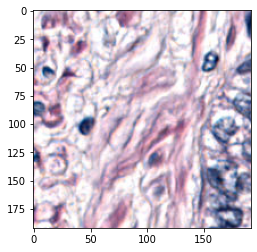

In [69]:
i = -2
x = pd_meta.loc[indexes[i], "Y"]
y = pd_meta.loc[indexes[i], "X"]
PATCH_SIZE = 192
r = int(PATCH_SIZE/2)
plt.imshow(get_image_patch(image, (x, y), PATCH_SIZE))
plt.show()

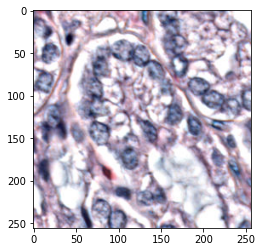

In [70]:
i = 400
x = pd_meta.loc[indexes[i], "Y"]
y = pd_meta.loc[indexes[i], "X"]
PATCH_SIZE = 256
r = int(PATCH_SIZE/2)
plt.imshow(get_image_patch(image, (x, y), PATCH_SIZE))
plt.show()

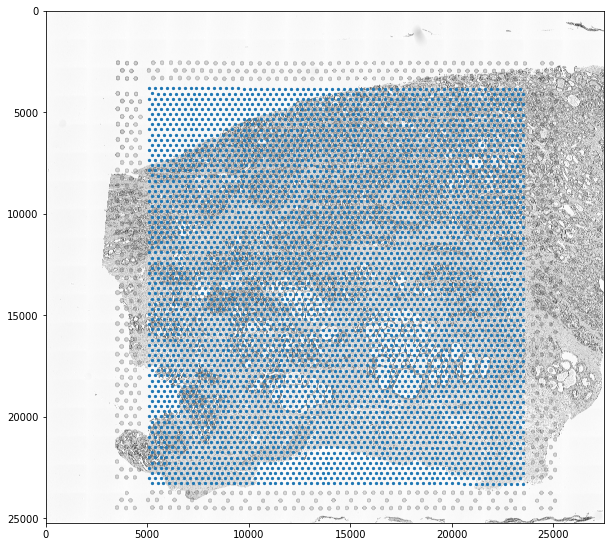

In [45]:
coords_x = pd_meta.loc[:, "Y"].values
coords_y = pd_meta.loc[:, "X"].values
plt.figure(figsize=(10, 10))
plt.imshow(image[..., 0]/255, cmap="gray")
plt.scatter(coords_x, coords_y, s=5)
plt.gca().set_aspect('equal')
plt.xlim(0, image.shape[1])
plt.ylim(image.shape[0], 0)
plt.show()

In [71]:
pd_count['TP53']

AAACAAGTATCTCCCA-1    0
AAACACCAATAACTGC-1    3
AAACAGAGCGACTCCT-1    2
AAACAGCTTTCAGAAG-1    0
AAACAGGGTCTATATT-1    0
                     ..
TTGTTGTGTGTCAAGA-1    3
TTGTTTCACATCCAGG-1    1
TTGTTTCATTAGTCTA-1    0
TTGTTTCCATACAACT-1    1
TTGTTTGTGTAAATTC-1    2
Name: TP53, Length: 4371, dtype: int64

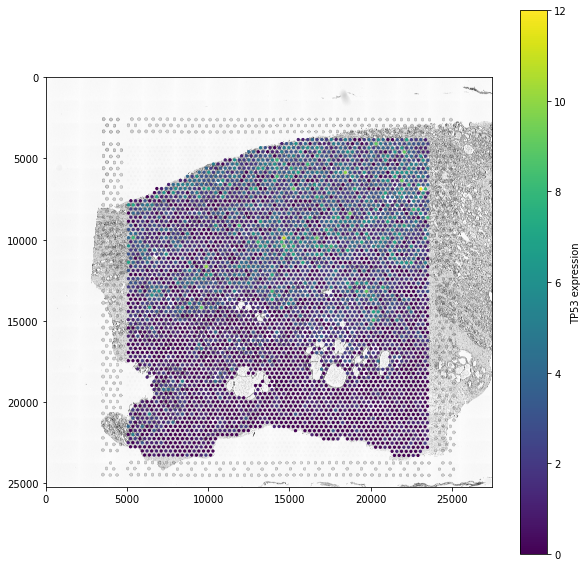

In [72]:
# Align by index
common_idx = pd_meta.index.intersection(pd_count.index)

coords_x = pd_meta.loc[common_idx, "Y"].values
coords_y = pd_meta.loc[common_idx, "X"].values
expr = pd_count.loc[common_idx, "TP53"].values

plt.figure(figsize=(10, 10))
plt.imshow(image[..., 0]/255, cmap="gray")

sc = plt.scatter(
    coords_x,
    coords_y,
    s=5,
    c=expr,
    cmap="viridis"
)

plt.gca().set_aspect('equal')
plt.xlim(0, image.shape[1])
plt.ylim(image.shape[0], 0)
plt.colorbar(sc, label="TP53 expression")
plt.show()


In [73]:
len(common_idx)

4371

In [74]:
pd_count

,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,C1orf159,...,SRY,ZFY,PCDH11Y,AMELY,TBL1Y,TSPY1,USP9Y,DDX3Y,TMSB4Y,KDM5D
AAACAAGTATCTCCCA-1,0,1,0,0,0,1,0,0,0,1,...,0,1,0,0,0,0,0,1,0,0
AAACACCAATAACTGC-1,1,1,0,0,0,2,0,2,0,0,...,0,0,0,0,0,0,0,2,0,2
AAACAGAGCGACTCCT-1,0,7,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
AAACAGCTTTCAGAAG-1,0,3,0,1,0,2,1,2,0,0,...,0,0,0,0,1,0,0,1,0,4
AAACAGGGTCTATATT-1,0,1,0,0,0,2,2,2,0,0,...,0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTGTGTGTCAAGA-1,0,0,0,0,0,3,0,2,0,0,...,0,0,0,0,0,0,0,2,0,2
TTGTTTCACATCCAGG-1,0,3,0,0,0,2,2,1,0,0,...,0,1,0,0,0,0,1,0,1,0
TTGTTTCATTAGTCTA-1,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
TTGTTTCCATACAACT-1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1


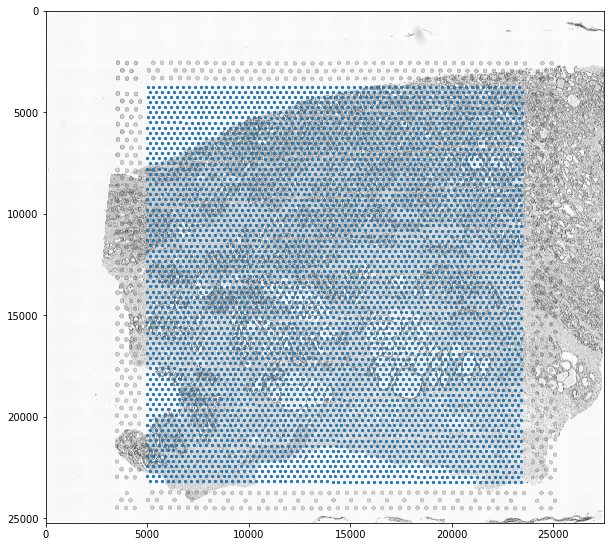

In [46]:
coords_x = pd_meta.loc[:, "Y"].values - 89
coords_y = pd_meta.loc[:, "X"].values - 89
plt.figure(figsize=(10, 10))
plt.imshow(image[..., 0]/255, cmap="gray")
plt.scatter(coords_x, coords_y, s=5)
plt.gca().set_aspect('equal')
plt.xlim(0, image.shape[1])
plt.ylim(image.shape[0], 0)
plt.show()

# Session Info

In [36]:
!pip freeze

argon2-cffi @ file:///tmp/build/80754af9/argon2-cffi_1613037492802/work
async-generator==1.10
attrs @ file:///opt/conda/conda-bld/attrs_1642510447205/work
backcall @ file:///home/ktietz/src/ci/backcall_1611930011877/work
bleach @ file:///opt/conda/conda-bld/bleach_1641577558959/work
cached-property==1.5.2
certifi==2021.5.30
cffi @ file:///tmp/build/80754af9/cffi_1625814693874/work
charset-normalizer==2.0.12
cycler==0.11.0
decorator==4.4.2
defusedxml @ file:///tmp/build/80754af9/defusedxml_1615228127516/work
entrypoints==0.3
googledrivedownloader==0.4
idna==3.10
imagecodecs==2020.5.30
imagecodecs-lite==2020.1.31
imageio==2.15.0
importlib-metadata @ file:///tmp/build/80754af9/importlib-metadata_1631916693255/work
importlib-resources==5.4.0
ipykernel==5.5.6
ipython @ file:///tmp/build/80754af9/ipython_1593447367857/work
ipython-genutils==0.2.0
jedi==0.17.2
Jinja2 @ file:///opt/conda/conda-bld/jinja2_1647436528585/work
jsonschema @ file:///Users/ktietz/demo/mc3/conda-bld/jsonschema_1630511